# Observação:
Antes de decidir minha pergunta e partir para a análise, eu explorei um pouco os mercados polymart e os mercados com mais transações, para analisar mercados grandes o suficiente para o alerta representar algo estatísticamente válido. Seguem as queries utilizadas para essa análise

SELECT \
    SUM(daily_trade_count) AS ntransacoes, 
    market_id, 
    event_title\
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`\
GROUP BY 
    market_id, 
    event_title\
ORDER BY 
    ntransacoes DESC\
LIMIT 200;

# Mercado escolhido:
# Trump ends Ukraine war in first 90 days?


# Pergunta 
Como se comportou o mercado com os momentos iniciais do governo de Trump?


In [9]:
import pandas as pd 
import matplotlib.pyplot as plt

Compreensão inicial do mercado e agregação dos valores de volume de transações e probabilidade diários

In [7]:

mercado = pd.read_csv('dados/compreensao_mercado.csv')

mask = ~mercado.columns.isin(['condition_id', 'token1', 'token2'])

mercado_clean = mercado.loc[:, mask]

print(mercado_clean.head())


   market_id                                  question                                    slug answer1 answer2  closed  active  archived outcome_prices        volume  event_id                              event_slug                               event_title                      created_at                        end_date                      updated_at  neg_risk
0     510319  Trump ends Ukraine war in first 90 days?  trump-wins-ends-ukraine-war-in-90-days     Yes      No       1       1         0     ['0', '1']  5.649198e+07     13551  trump-wins-ends-ukraine-war-in-90-days  Trump ends Ukraine war in first 90 days?  2024-10-21 18:09:12.000000 UTC  2025-04-20 12:00:00.000000 UTC  2026-04-16 00:19:43.000000 UTC         0


# Dados agregados de probabilidade e volume do primeiro mês de governo do Trump (2 primeiros meses)

Obs: usei só os dois primeiros meses para obter um comportamento mais radical, e não o esperado comportamento de decrescimento de probabilidade com o passar do tempo (perto de expirar o prazo)

# Query SQL

In [ ]:
--CÓDIGO SQL, APENAS PARA MOSTRAR, NÃO É PARA RODAR NO NOTEBOOK
--Transações com preço e número de tokens
WITH transacoes_filtradas AS (
    SELECT 
        DATE(trade_timestamp) AS data_trade,
        nonusdc_side AS ResultadoEvento,
        price,
        token_amount
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE market_id = '510319'
      AND (DATE(trade_timestamp) BETWEEN '2025-01-01' AND '2025-01-31')
),
--Agregação diária padrão
agregacao_diaria AS (
    SELECT 
        data_trade,
        ResultadoEvento,
        SUM(price * token_amount) / SUM(token_amount) AS vwap_probabilidade,
        SUM(token_amount) AS volume_diario
    FROM transacoes_filtradas
    GROUP BY data_trade, ResultadoEvento
)
--Valores de probabilidade e volume diário 
SELECT 
    data_trade,
    MAX(CASE WHEN ResultadoEvento = 'token1' THEN vwap_probabilidade END) AS prob_yes,
    MAX(CASE WHEN ResultadoEvento = 'token2' THEN vwap_probabilidade END) AS prob_no,
    MAX(CASE WHEN ResultadoEvento = 'token1' THEN volume_diario END) AS vol_yes,
    MAX(CASE WHEN ResultadoEvento = 'token2' THEN volume_diario END) AS vol_no
FROM agregacao_diaria
GROUP BY data_trade
ORDER BY data_trade;



In [34]:
dados_mercado = pd.read_csv("dados/agregacoes_simples_fevereirotambem.csv")
dados_mercado['data_trade'] = pd.to_datetime(dados_mercado['data_trade'])

# Avaliação Volume

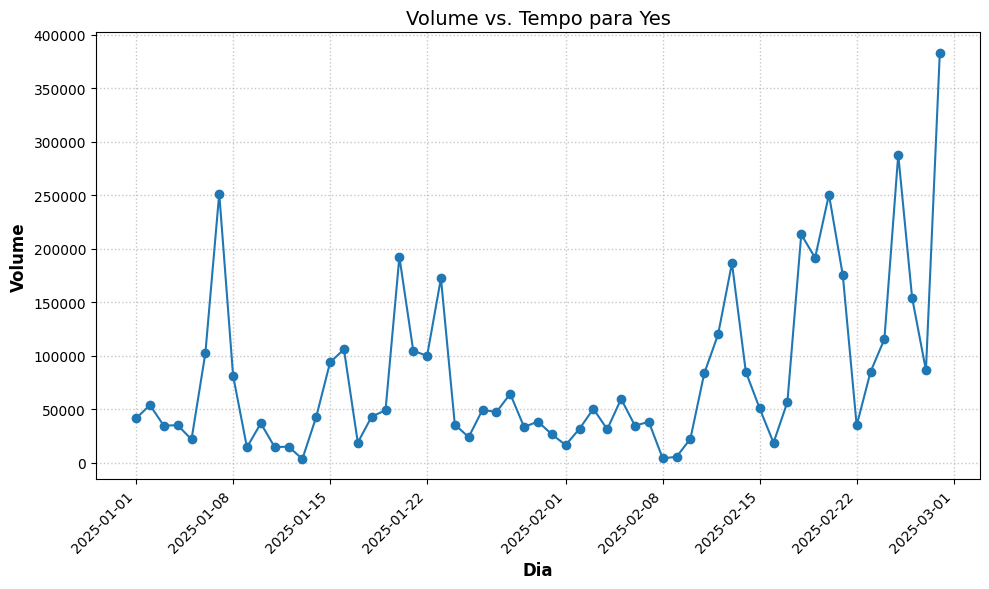

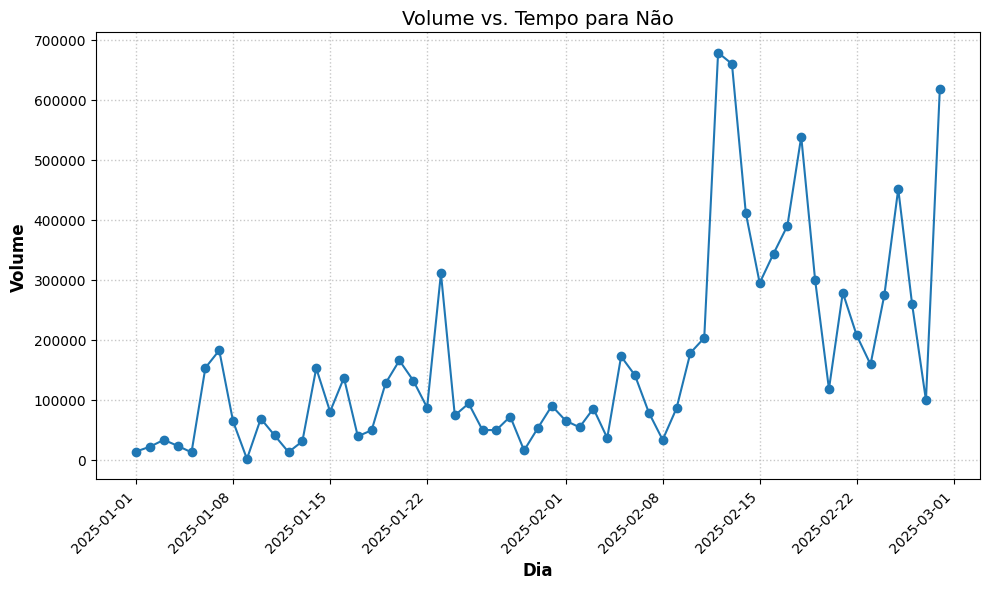

In [35]:

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(dados_mercado['data_trade'], dados_mercado['vol_yes'], 
        color='#1f77b4', linestyle='-', marker='o', label='Yes')
ax.set_xlabel('Dia', fontsize=12, fontweight='bold')
ax.set_ylabel('Volume', fontsize=12, fontweight='bold')
ax.set_title('Volume vs. Tempo para Yes', fontsize=14)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.grid(True, which='major', axis='both', linestyle=':', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dados_mercado['data_trade'], dados_mercado['vol_no'], 
        color='#1f77b4', linestyle='-', marker='o', label='Yes')
ax.set_xlabel('Dia', fontsize=12, fontweight='bold')
ax.set_ylabel('Volume', fontsize=12, fontweight='bold')
ax.set_title('Volume vs. Tempo para Não', fontsize=14)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.grid(True, which='major', axis='both', linestyle=':', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.show()


# Avaliação Prob Implícita

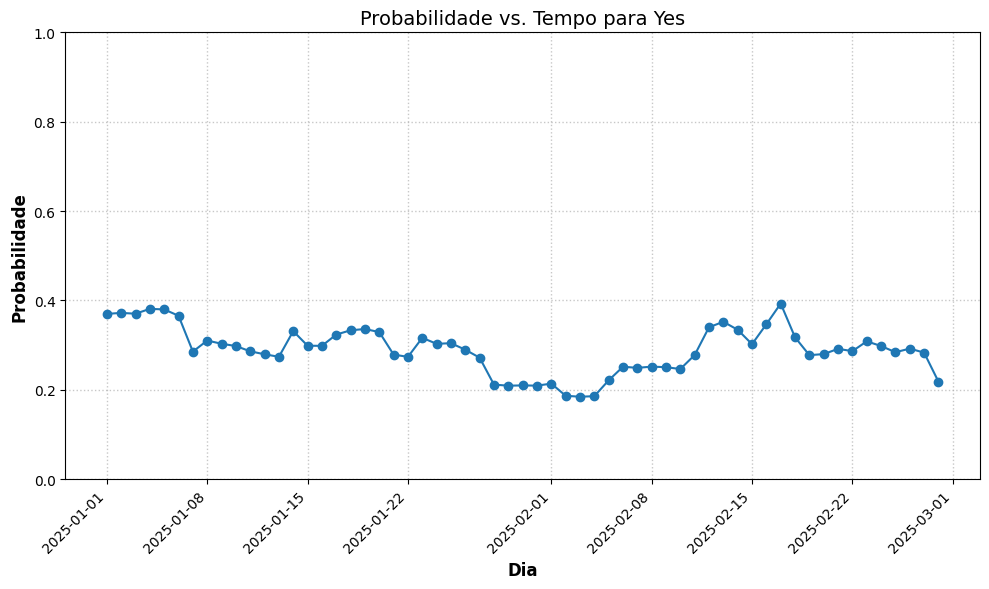

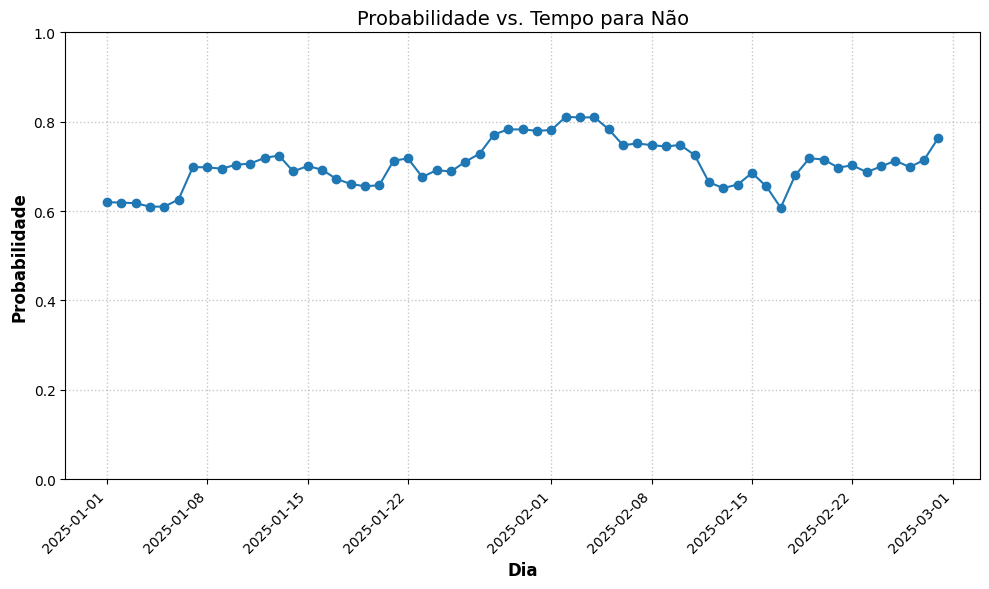

In [36]:

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(dados_mercado['data_trade'], dados_mercado['prob_yes'], 
        color='#1f77b4', linestyle='-', marker='o', label='Yes')
ax.set_xlabel('Dia', fontsize=12, fontweight='bold')
ax.set_ylabel('Probabilidade', fontsize=12, fontweight='bold')
ax.set_title('Probabilidade vs. Tempo para Yes', fontsize=14)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(bottom=0, top=1)
ax.grid(True, which='major', axis='both', linestyle=':', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dados_mercado['data_trade'], dados_mercado['prob_no'], 
        color='#1f77b4', linestyle='-', marker='o', label='Yes')
ax.set_xlabel('Dia', fontsize=12, fontweight='bold')
ax.set_ylabel('Probabilidade', fontsize=12, fontweight='bold')
ax.set_title('Probabilidade vs. Tempo para Não', fontsize=14)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(bottom=0, top=1)
ax.grid(True, which='major', axis='both', linestyle=':', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.show()


# Agregações mais complexas: spread e desvio padrão diário

Query SQL

In [ ]:
--Query SQL, não rode no notebook!
--Transações com preço e número de tokens
WITH transacoes_filtradas AS (
    SELECT 
        DATE(trade_timestamp) AS data_trade,
        nonusdc_side AS ResultadoEvento,
        price,
        token_amount
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE market_id = '510319'
      AND (DATE(trade_timestamp) BETWEEN '2025-01-01' AND '2025-02-28')
)
SELECT 
    data_trade,
    MAX(CASE WHEN ResultadoEvento = 'token1' THEN (price) END) AS preco_maximo_yes,
    MIN(CASE WHEN ResultadoEvento = 'token1' THEN (price) END) AS preco_minimo_yes,
    MAX(CASE WHEN ResultadoEvento = 'token1'THEN price END)- MIN(CASE WHEN ResultadoEvento = 'token1' THEN (price) END)
    AS spread_intradiario_yes,
    COALESCE(STDDEV_SAMP(CASE WHEN ResultadoEvento = 'token1'THEN (price) END)) AS desvio_padrao_preco_yes,
    MAX(CASE WHEN ResultadoEvento = 'token2' THEN (price) END) AS preco_maximo_no,
    MIN(CASE WHEN ResultadoEvento = 'token2' THEN (price) END) AS preco_minimo_no,
    MAX(CASE WHEN ResultadoEvento = 'token2'THEN price END)- MIN(CASE WHEN ResultadoEvento = 'token2' THEN (price) END)
    AS spread_intradiario_no,
    COALESCE(STDDEV_SAMP(CASE WHEN ResultadoEvento = 'token2'THEN (price) END)) AS desvio_padrao_preco_no

FROM transacoes_filtradas
GROUP BY data_trade
ORDER BY data_trade ASC;

In [37]:
dados_2_mercado = pd.read_csv('dados/agregacoes_complexas_fevereirotambem.csv')
dados_2_mercado['data_trade'] = pd.to_datetime(dados_2_mercado['data_trade'])

Spread e DP para yes

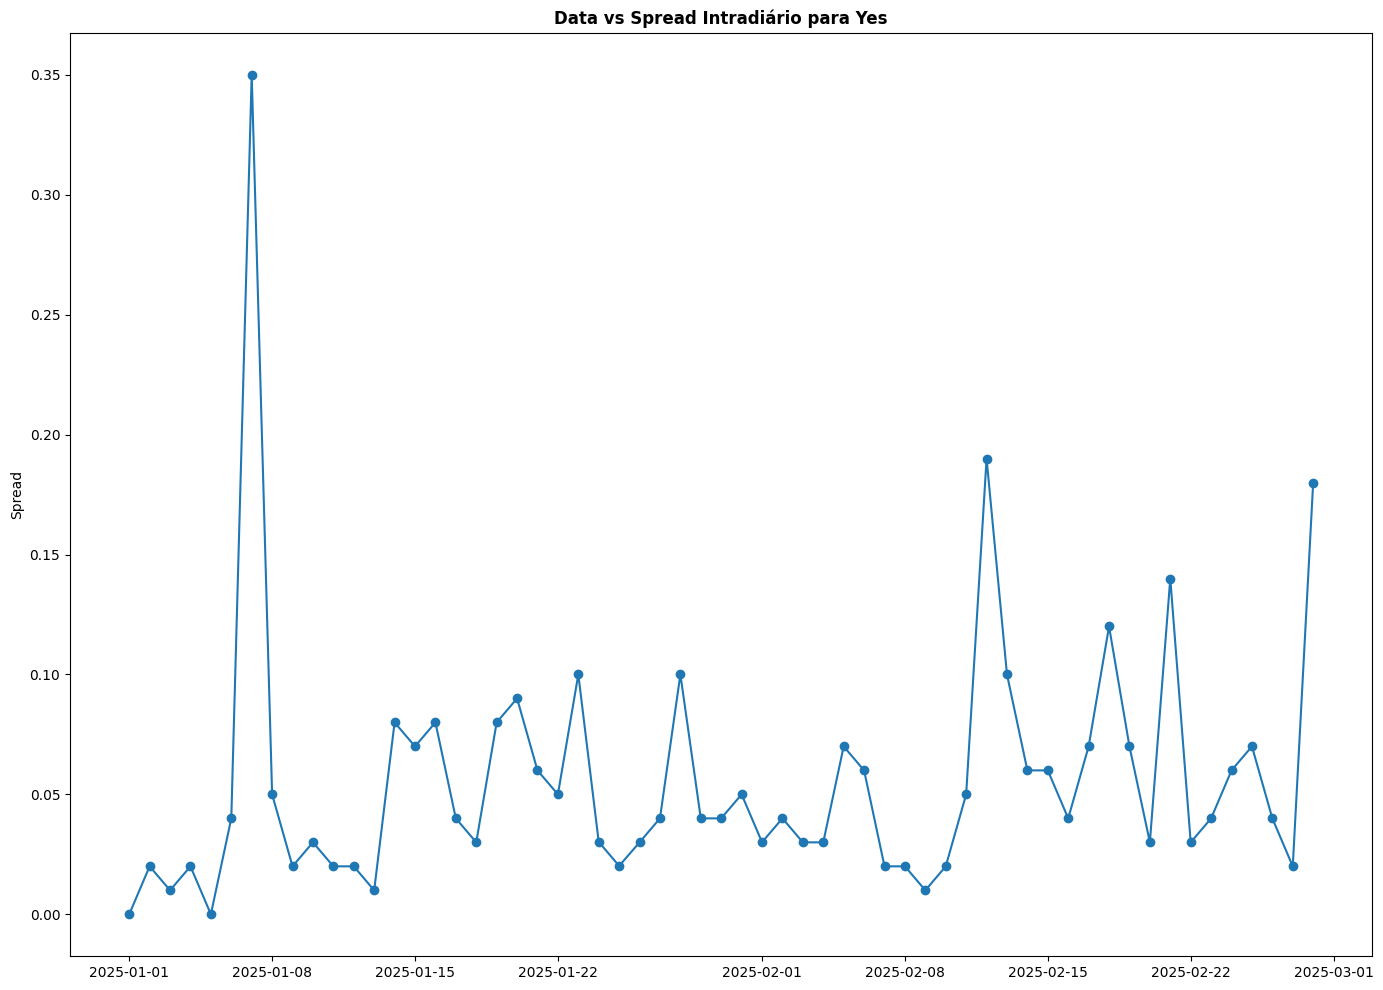

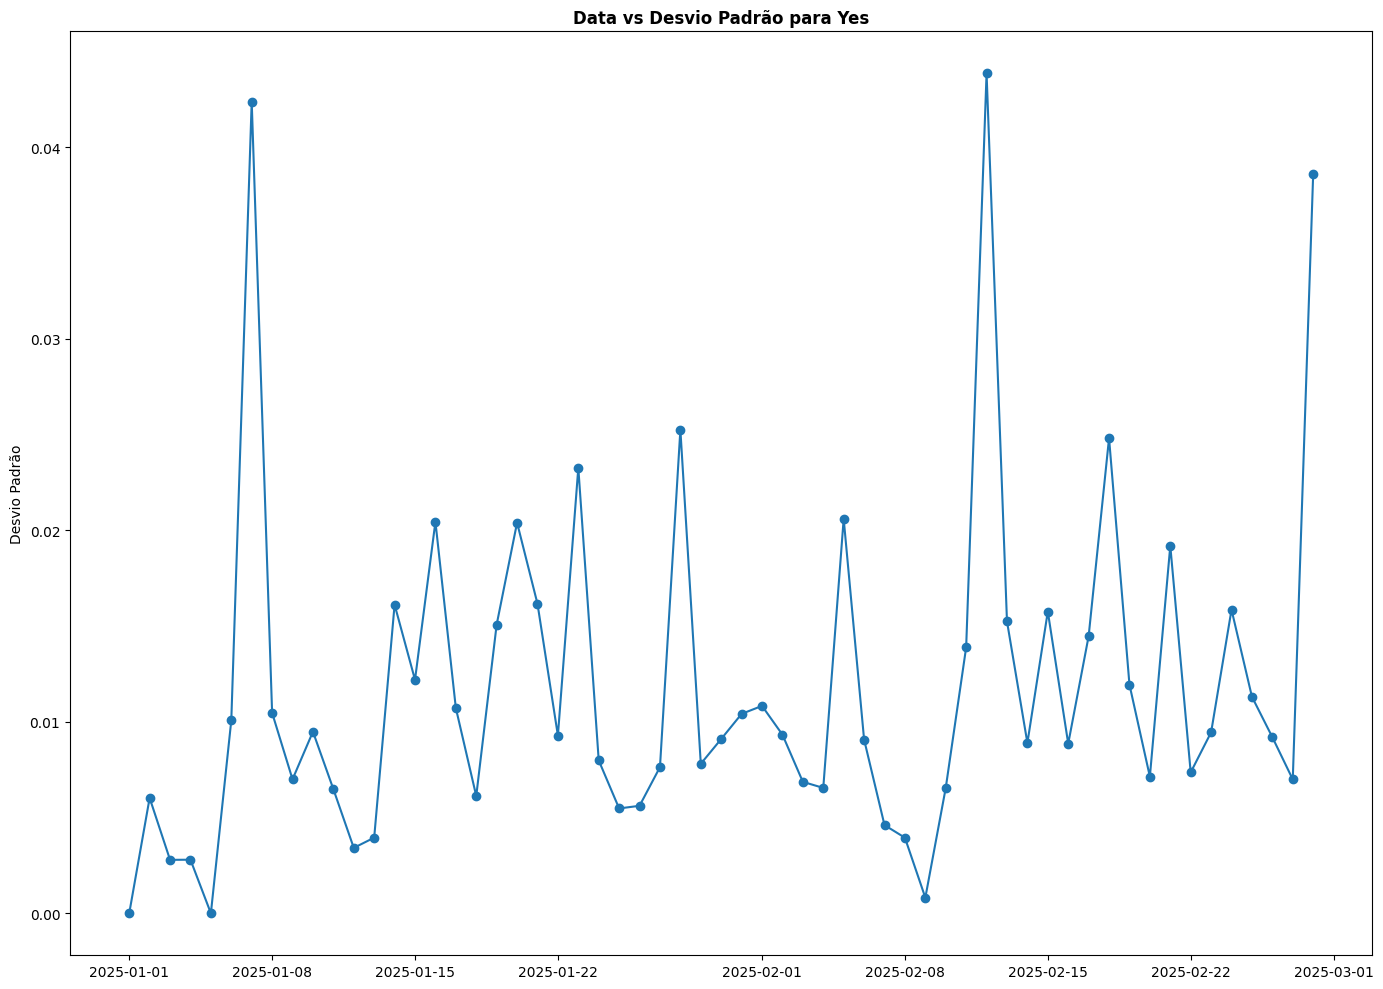

In [39]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(14, 10))

axs.plot(dados_2_mercado['data_trade'], dados_2_mercado['spread_intradiario_yes'], 
               color='#1f77b4', marker='o', linestyle='-')
axs.set_title('Data vs Spread Intradiário para Yes', fontweight='bold')
axs.set_ylabel('Spread')
plt.tight_layout()
plt.show()
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(14, 10))

axs.plot(dados_2_mercado['data_trade'], dados_2_mercado['desvio_padrao_preco_yes'], 
               color='#1f77b4', marker='o', linestyle='-')
axs.set_title('Data vs Desvio Padrão para Yes', fontweight='bold')
axs.set_ylabel('Desvio Padrão')


plt.tight_layout()
plt.show()

Spread e DP para no

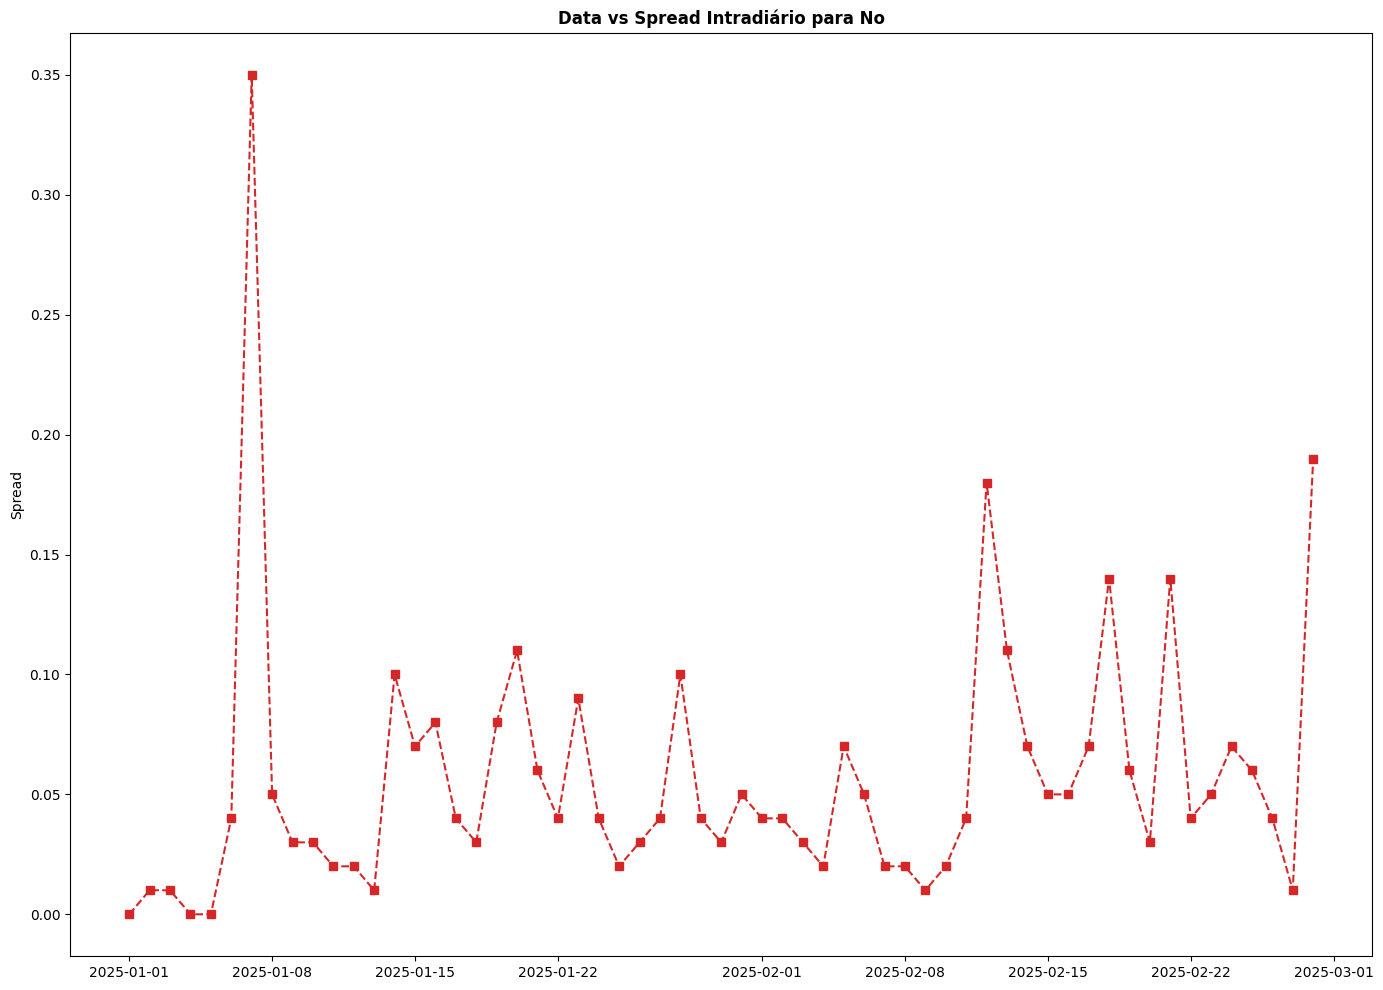

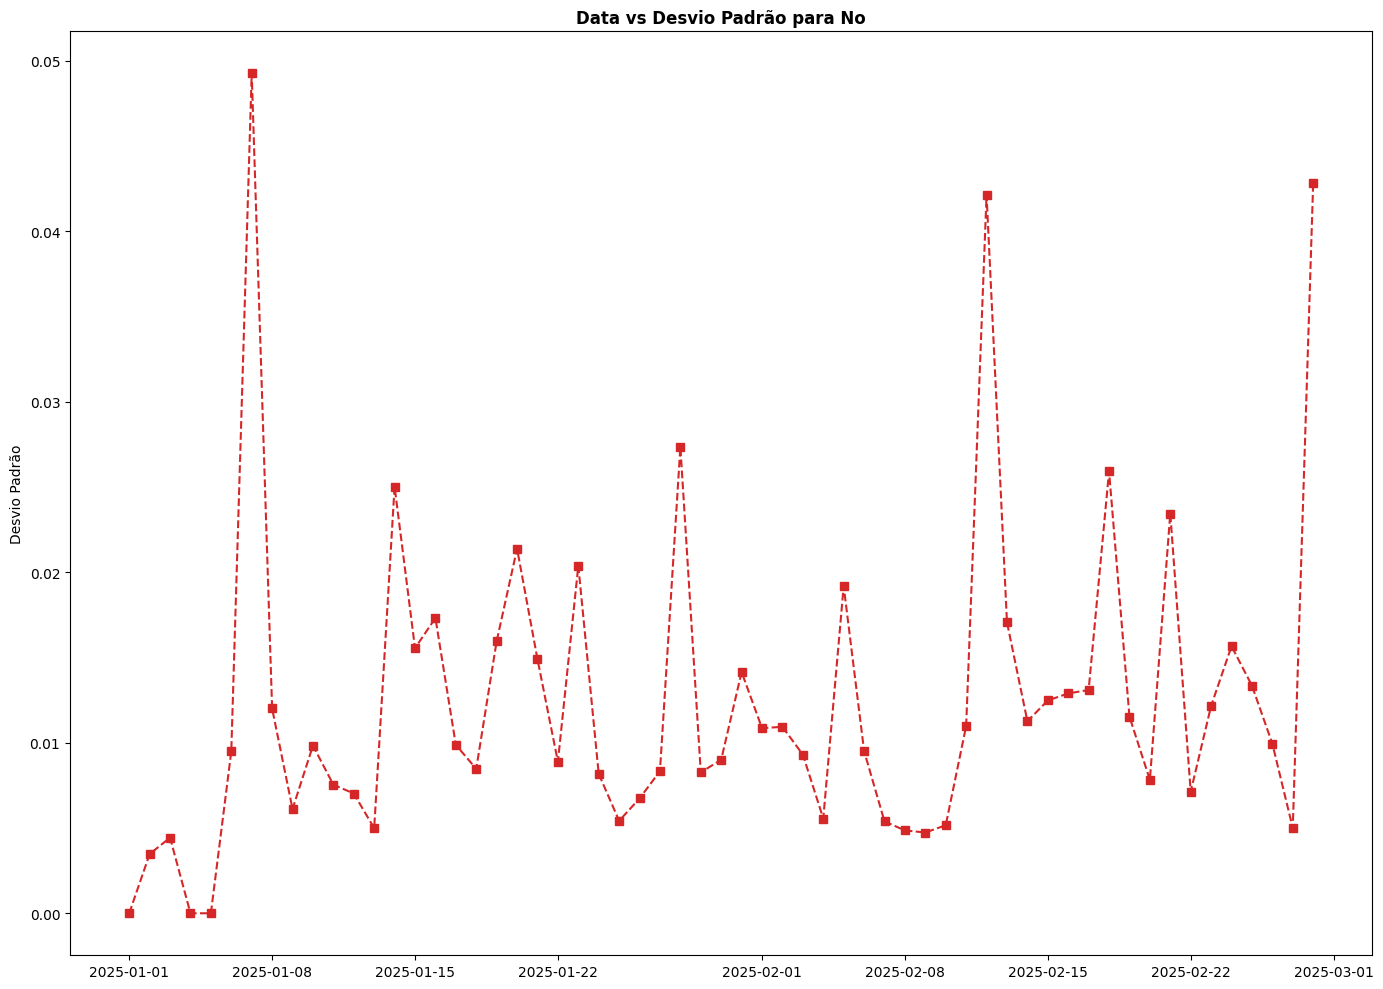

In [41]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(14, 10))

axs.plot(dados_2_mercado['data_trade'], dados_2_mercado['spread_intradiario_no'], 
               color='#d62728', marker='s', linestyle='--')
axs.set_title('Data vs Spread Intradiário para No', fontweight='bold')
axs.set_ylabel('Spread')
plt.tight_layout()
plt.show()
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(14, 10))

axs.plot(dados_2_mercado['data_trade'], dados_2_mercado['desvio_padrao_preco_no'], 
               color='#d62728', marker='s', linestyle='--')
axs.set_title('Data vs Desvio Padrão para No', fontweight='bold')
axs.set_ylabel('Desvio Padrão')
plt.tight_layout()
plt.show()

# Alertas: Z-Score para variação da probabilidade e limiar de dominância em dólares do No.

In [ ]:
--Query em SQL para os alertas
WITH transacoes_filtradas AS (
    SELECT 
        DATE(trade_timestamp) AS data_trade,
        nonusdc_side AS resultado_evento,
        price,
        token_amount
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE market_id = '510319'
      AND (DATE(trade_timestamp) BETWEEN '2025-01-01' AND '2025-02-28')
),

agregacao_diaria AS (
    SELECT 
        data_trade,
        -- Preço Médio Ponderado por Volume para Yes: probabilidade do yes
        SUM(CASE WHEN resultado_evento = 'token1' THEN price * token_amount END) / 
            NULLIF(SUM(CASE WHEN resultado_evento = 'token1' THEN token_amount END), 0) AS vwap_yes,
            
        -- Agregação em dólares (Preço * Quantidade)
        SUM(CASE WHEN resultado_evento = 'token1' THEN price * token_amount ELSE 0 END) AS volume_usd_yes,
        SUM(CASE WHEN resultado_evento = 'token2' THEN price * token_amount ELSE 0 END) AS volume_usd_no,
        SUM(price * token_amount) AS volume_usd_total
    FROM transacoes_filtradas
    GROUP BY data_trade
),

calculo_dominancia_delta AS (
    SELECT
        data_trade,
        vwap_yes,
        volume_usd_yes,
        volume_usd_no,
        volume_usd_total,
        
        -- Cálculo da proporção do capital alocado na cota 'No' (token2)
        CASE 
            WHEN volume_usd_total > 0 THEN volume_usd_no / volume_usd_total
            ELSE 0 
        END AS dominancia_no,
        
        -- Cálculo primário da variação direcional de preço da cota 'Yes'
        (vwap_yes - LAG(vwap_yes) OVER (ORDER BY data_trade)) AS delta_preco_yes
    FROM agregacao_diaria
),

metricas_moveis AS (
    SELECT
        data_trade,
        vwap_yes,
        delta_preco_yes,
        volume_usd_total,
        dominancia_no,
        
        -- Janela Móvel: Média de dominância do 'No' (7 dias retroativos)
        AVG(dominancia_no) OVER (ORDER BY data_trade ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS media_dominancia_no_7d,
        
        -- Janelas Móveis da variação diário da probabilidade
        AVG(delta_preco_yes) OVER (ORDER BY data_trade ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS media_delta_7d,
        COALESCE(STDDEV_SAMP(delta_preco_yes) OVER (ORDER BY data_trade ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING), 0) AS desvio_delta_7d
    FROM calculo_dominancia_delta
),

calculo_zscore AS (
    SELECT
        *,
        -- Lidar com o caso de valor=média
        CASE 
            WHEN desvio_delta_7d > 0 THEN (delta_preco_yes - media_delta_7d) / desvio_delta_7d
            ELSE 0 
        END AS z_score_yes
    FROM metricas_moveis
)

SELECT
    data_trade,
    ROUND(vwap_yes, 4) AS preco_medio_yes,
    ROUND(delta_preco_yes, 4) AS variacao_preco_yes,
    ROUND(z_score_yes, 2) AS z_score_preco,
    ROUND(dominancia_no, 4) AS taxa_dominancia_no,
    ROUND(media_dominancia_no_7d, 4) AS media_dominancia_no_7d,
    ROUND(volume_usd_total, 2) AS volume_total_diario,
    
    -- Regras de categorização (nome) de disparo
    CASE 
        WHEN ABS(z_score_yes) >= 2.0 AND (dominancia_no > 0.70 AND dominancia_no > (media_dominancia_no_7d * 1.5)) 
             THEN 'Alerta Duplo: Choque de Preco e Fuga Sistêmica de Capital'
        WHEN ABS(z_score_yes) >= 2.0 
             THEN 'Alerta 1: Choque de Preco (Z-Score >= 2)'
        WHEN dominancia_no > 0.70 AND dominancia_no > (media_dominancia_no_7d * 1.5) 
             THEN 'Alerta 2: Inversao Agressiva de Dominancia de Fluxo'
        ELSE NULL
    END AS tipo_alerta

FROM calculo_zscore
WHERE 
    (ABS(z_score_yes) >= 2.5)
    OR 
    (dominancia_no > 0.80 AND dominancia_no > (media_dominancia_no_7d * 1.5))
ORDER BY data_trade;

# Alertas para o período específicado 
 (2 primeiros meses: levando em consideração os parâmetros 2.5 para ao Z-score, dominância do No em 80% globalmente e 50% maior do que a média semanal)

In [42]:
resultado_alerta_periodo_1 = pd.read_csv('dados/resultados_alertas.csv')
print(resultado_alerta_periodo_1)

   data_trade  preco_medio_yes  variacao_preco_yes  z_score_preco  taxa_dominancia_no  media_dominancia_no_7d  volume_total_diario                                        tipo_alerta
0  2025-01-04           0.3813              0.0109           3.64              0.5182                  0.4625             27646.90           Alerta 1: Choque de Preco (Z-Score >= 2)
1  2025-01-06           0.3659             -0.0141          -2.83              0.7197                  0.4780            133531.81  Alerta Duplo: Choque de Preco e Fuga Sistêmica...
2  2025-01-07           0.2856             -0.0803          -8.81              0.6397                  0.5183            199455.86           Alerta 1: Choque de Preco (Z-Score >= 2)
3  2025-01-11           0.2863             -0.0119          -0.05              0.8747                  0.5758             32966.45  Alerta 2: Inversao Agressiva de Dominancia de ...
4  2025-02-05           0.2214              0.0355           3.69              0.9113     

Isso demonstra o grande ruído que eu tive de hipótese anteriormente, as probabilidades mudaram massivamente em praticamente todos esses casos, que corresponde à mais de 10% do intervalo de dias especificado. Pesquisando afundo, descobri que houve movimentações que justificassem essas mudanças: reuniões, falas, etc...

# Validação do alerta

Agora, para validar o alerta, vou aplica-lo no resto do período do mercado, não somente os dois primeiros meses do governo, para entender se casos extraordinários também são capturados.
A query é praticamente igual, só muda o campo a seguir

In [ ]:
    (DATE(trade_timestamp) BETWEEN '2024-10-21' AND '2025-01-01'
      OR
    (DATE(trade_timestamp) BETWEEN '2025-02-28' AND '2025-04-20'))


E o resultado foi

In [45]:
resultado_alerta_extendido = pd.read_csv('dados/resultados_alertas_periodoextendido.csv')
print(resultado_alerta_extendido)

    data_trade  preco_medio_yes  variacao_preco_yes  z_score_preco  taxa_dominancia_no  media_dominancia_no_7d  volume_total_diario                                        tipo_alerta
0   2024-10-27           0.3679              0.1002           4.70              0.9300                  0.8582              8167.40           Alerta 1: Choque de Preco (Z-Score >= 2)
1   2024-11-06           0.4158              0.1105           6.19              0.4209                  0.7973            152594.61           Alerta 1: Choque de Preco (Z-Score >= 2)
2   2024-11-17           0.4206             -0.0371          -2.71              0.6273                  0.5229             52721.30           Alerta 1: Choque de Preco (Z-Score >= 2)
3   2024-11-28           0.4296              0.0196           3.15              0.5335                  0.5404             23221.91           Alerta 1: Choque de Preco (Z-Score >= 2)
4   2024-12-07           0.4314              0.0014           0.13              0.855

A conclusão, após pesquisar, é que, fora os últimos, que eram fortemente esperados pela proximidade do fim do prazo, todos os outros também foram acompanhados por e fatores externos relevanetes, como reuniões e tomadas de decisão.


# Resposta hipótese inicial

Apesar de, inicialmente, eu achar que o **ruído de comunicação** do Trump, como declarações de ministros, etc, seria determinante para a flutuação do mercado, as flutuações foram pautadas principalmente em **reuniões e acontecimentos concretos**, o que invalida, parcialmente, a minha hipótese inicial